In [19]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# **PROJECT**
# **Comment Category Prediction Challenge :** 

# Imports Libraries

In [20]:
# Imports 

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import gc
import psutil

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report

# Data Loading

In [21]:
DATA_PATH = "/kaggle/input/comment-category-prediction-challenge/"

train  = pd.read_csv(train_path)
test   = pd.read_csv(test_path)
sample = pd.read_csv(sample_path)

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Sample shape:", sample.shape)


Train shape: (198000, 15)
Test shape: (102000, 14)
Sample shape: (102000, 2)


# Data Cleaning

In [22]:
# Data Cleaning

for df in [train, test]:
    df['created_date'] = pd.to_datetime(df['created_date'], errors='coerce', utc=True)
    for col in ['race', 'religion', 'gender']:
        df[col] = df[col].fillna('unknown')
    df['comment']    = df['comment'].fillna('')
    df['disability'] = df['disability'].fillna(0).astype(int)
    for col in ['upvote', 'downvote', 'if_1', 'if_2',
                'emoticon_1', 'emoticon_2', 'emoticon_3']:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

print('Nulls remaining:', train.isnull().sum().sum())
print('All clean!' if train.isnull().sum().sum() == 0 else 'WARNING: nulls remain')

Nulls remaining: 0
All clean!


# Text Cleaning

In [23]:
# Text Cleaning


def clean_comment(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', ' url ', text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-z0-9\s!?]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

train['clean_comment'] = train['comment'].apply(clean_comment)
test['clean_comment']  = test['comment'].apply(clean_comment)

print('Text cleaning done.')
print('Sample:', train['clean_comment'].iloc[0][:100])

Text cleaning done.
Sample: she might be a bright spot for a party keou on oahu dominated by greedy criminals or ethically chall


# **EDA** :

# Dataset Overview

In [24]:
print('DATASET OVERVIEW')

print(f'\nTrain shape : {train.shape}')
print(f'Test  shape : {test.shape}')

DATASET OVERVIEW

Train shape : (198000, 16)
Test  shape : (102000, 15)


In [25]:
print('Column Info')
print(train.dtypes)

Column Info
created_date     datetime64[ns, UTC]
post_id                        int64
emoticon_1                     int64
emoticon_2                     int64
emoticon_3                     int64
upvote                         int64
downvote                       int64
if_1                           int64
if_2                           int64
race                          object
religion                      object
gender                        object
disability                     int64
comment                       object
label                          int64
clean_comment                 object
dtype: object


In [26]:
print('Basic Statistics')
display(train.describe().round(2))

Basic Statistics


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,label
count,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00,198000.00
mean,68.45,0.28,0.05,0.12,2.61,0.67,1.91,7.96,0.01,0.79
std,27.95,1.02,0.26,0.48,5.05,2.04,25.64,14.84,0.12,0.98
min,20.00,0.00,0.00,0.00,0.00,0.00,0.00,3.00,0.00,0.00
25%,39.00,0.00,0.00,0.00,0.00,0.00,0.00,4.00,0.00,0.00
50%,72.00,0.00,0.00,0.00,1.00,0.00,0.00,6.00,0.00,0.00
75%,72.00,0.00,0.00,0.00,3.00,1.00,4.00,10.00,0.00,2.00
max,129.00,47.00,11.00,17.00,201.00,107.00,1860.00,1833.00,1.00,3.00


# Missing Values Analysis

In [27]:
if train.isnull().sum().sum() == 0:
    print("No missing values in dataset.")
else:
    print("Missing values found.")

No missing values in dataset.


# Target Label Distribution

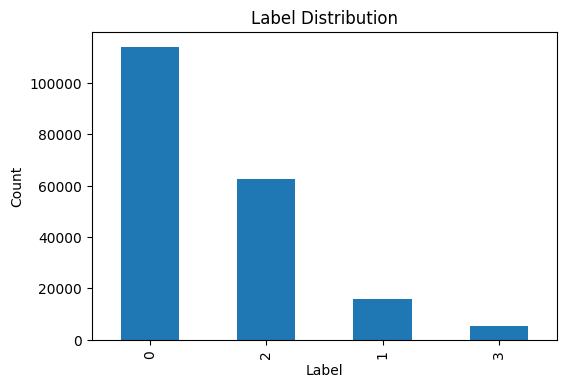

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64


In [28]:
plt.figure(figsize=(6,4))
train['label'].value_counts().plot(kind='bar')
plt.title("Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

print(train['label'].value_counts(normalize=True))


# Comment Text Analysis

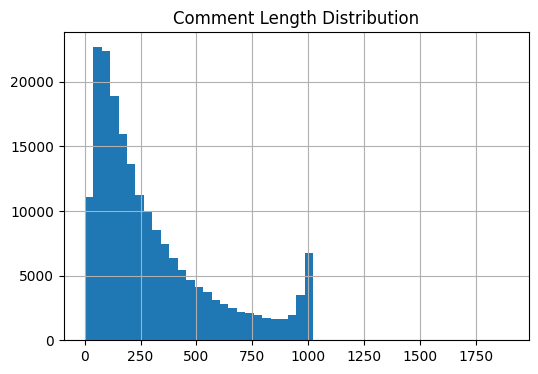

count    198000.000000
mean        302.909364
std         266.441749
min           0.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

In [29]:
train['comment'] = train['comment'].astype(str)
train['comment_length'] = train['comment'].apply(len)

plt.figure(figsize=(6,4))
train['comment_length'].hist(bins=50)
plt.title("Comment Length Distribution")
plt.show()

train['comment_length'].describe()


# Correlation Heatmap

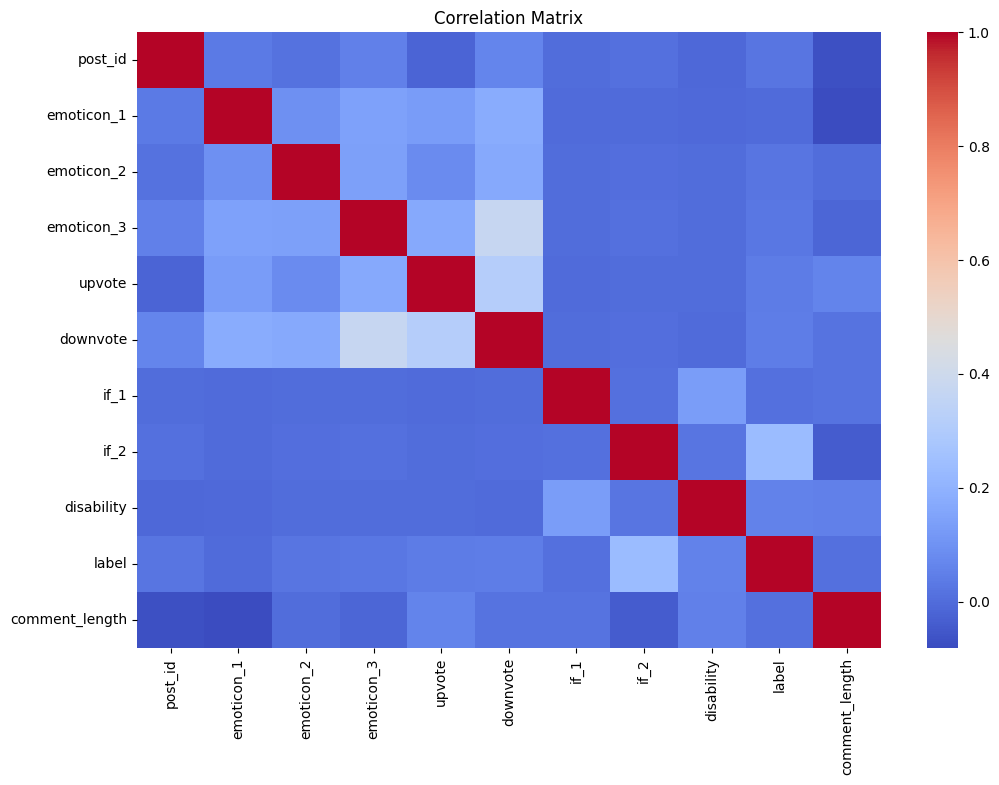

In [30]:
numeric_data = train.select_dtypes(include=np.number)

plt.figure(figsize=(12,8))
sns.heatmap(numeric_data.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


# **Feature Engineering** :

In [31]:

# Feature Engineering 


import gc

for df in [train, test]:

    # Datetime
    df['year']       = df['created_date'].dt.year
    df['month']      = df['created_date'].dt.month
    df['day']        = df['created_date'].dt.day
    df['hour']       = df['created_date'].dt.hour
    df['dayofweek']  = df['created_date'].dt.dayofweek
    df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

    # Text stats
    df['comment_length']    = df['comment'].apply(len)
    df['word_count']        = df['comment'].apply(lambda x: len(x.split()))
    df['avg_word_length']   = df['comment_length'] / (df['word_count'] + 1)
    df['exclamation_count'] = df['comment'].str.count('!')
    df['question_count']    = df['comment'].str.count(r'\?')
    df['uppercase_ratio']   = df['comment'].apply(
        lambda x: sum(1 for c in x if c.isupper()) / (len(x) + 1))
    df['unique_words_ratio'] = df['clean_comment'].apply(
        lambda x: len(set(x.split())) / (len(x.split()) + 1) if x.split() else 0)
    df['punctuation_count'] = df['comment'].str.count(r'[!?.,;:]')
    df['punctuation_ratio'] = df['punctuation_count'] / (df['comment_length'] + 1)
    df['url_count']         = df['comment'].str.count(r'http\S+|www\S+')
    df['sentence_count']    = df['comment'].str.count(r'[.!?]') + 1
    df['avg_sentence_len']  = df['word_count'] / (df['sentence_count'] + 1)
    df['cap_word_count']    = df['comment'].apply(
        lambda x: sum(1 for w in x.split() if w.isupper() and len(w) > 1))
    df['repeat_char']       = df['comment'].apply(
        lambda x: len(re.findall(r'(.)\1{2,}', x)))
    df['toxic_punc']        = df['comment'].str.count(r'[!?]{2,}')
    df['has_url']           = (df['url_count'] > 0).astype(int)

    # Vote features
    df['vote_ratio']     = df['upvote'] / (df['downvote'] + 1)
    df['total_votes']    = df['upvote'] + df['downvote']
    df['vote_sentiment'] = df['upvote'] - df['downvote']
    df['log_upvote']     = np.log1p(df['upvote'])
    df['log_downvote']   = np.log1p(df['downvote'])
    df['vote_diff_log']  = np.log1p(df['upvote']) - np.log1p(df['downvote'])

    # Emoticon features
    df['total_emoticons']  = df['emoticon_1'] + df['emoticon_2'] + df['emoticon_3']
    df['has_any_emoticon'] = (df['total_emoticons'] > 0).astype(int)
    df['emoticon_ratio']   = df['total_emoticons'] / (df['word_count'] + 1)

    # if_2 bucket features 
    df['if_2_is_10'] = (df['if_2'] == 10).astype(int)
    df['if_2_is_4']  = (df['if_2'] == 4).astype(int)
    df['if_2_is_11'] = (df['if_2'] == 11).astype(int)

    # FIXED LINE 
    df['if_2_bucket'] = pd.cut(
        df['if_2'],
        bins=[-1, 0, 4, 9, 14, 999],
        labels=False
    ).fillna(-1).astype(int)

    # Interaction features
    df['if1_if2_product'] = df['if_1'] * df['if_2']
    df['if1_x_dis']       = df['if_1'] * df['disability']
    df['if2_x_downvote']  = df['if_2'] * df['downvote']
    df['if1_x_upvote']    = df['if_1'] * df['upvote']
    df['if2_x_len']       = df['if_2'] * df['comment_length']
    df['downvote_x_len']  = df['downvote'] * df['comment_length']

# Drop created_date
train.drop(columns=['created_date'], inplace=True)
test.drop(columns=['created_date'], inplace=True)

gc.collect()

print('Feature engineering done. Train shape:', train.shape)

Feature engineering done. Train shape: (198000, 56)


#  Post Features

In [32]:
# Post-Level Aggregation + Bayesian Target Encoding


def add_post_features(df, reference_df=None):
    src = reference_df if reference_df is not None else df
    post_stats = src.groupby('post_id').agg(
        post_upvote_mean   = ('upvote',   'mean'),
        post_upvote_std    = ('upvote',   'std'),
        post_upvote_max    = ('upvote',   'max'),
        post_downvote_mean = ('downvote', 'mean'),
        post_downvote_std  = ('downvote', 'std'),
        post_downvote_max  = ('downvote', 'max'),
        post_comment_count = ('upvote',   'count')
    ).reset_index()
    if 'label' in src.columns:
        global_label_mean = src['label'].mean()
        k = 5
        label_agg = src.groupby('post_id')['label'].agg(
            _sum='sum', _count='count').reset_index()
        label_agg['post_label_mean'] = (
            (label_agg['_sum'] + global_label_mean * k)
            / (label_agg['_count'] + k))
        label_agg['post_label_std'] = \
            src.groupby('post_id')['label'].std().fillna(0).values
        label_agg = label_agg[['post_id', 'post_label_mean', 'post_label_std']]
        post_stats = post_stats.merge(label_agg, on='post_id', how='left')
    df = df.merge(post_stats, on='post_id', how='left')
    return df

train = add_post_features(train)
test  = add_post_features(test, reference_df=train)

post_cols = [c for c in train.columns if c.startswith('post_')]
train[post_cols] = train[post_cols].fillna(0)
test[post_cols]  = test[post_cols].fillna(0)

gc.collect()
print('Post features added:', post_cols)
print('Train shape:', train.shape)

Post features added: ['post_id', 'post_upvote_mean', 'post_upvote_std', 'post_upvote_max', 'post_downvote_mean', 'post_downvote_std', 'post_downvote_max', 'post_comment_count', 'post_label_mean', 'post_label_std']
Train shape: (198000, 65)


# TF-IDF Vectorization

In [33]:
# TF-IDF Vectorization 

from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix

tfidf_word = TfidfVectorizer(
    max_features  = 50000,
    ngram_range   = (1, 2),
    min_df        = 3,
    max_df        = 0.95,
    sublinear_tf  = True,
    strip_accents = 'unicode'
)

tfidf_char = TfidfVectorizer(
    max_features  = 30000,
    analyzer      = 'char_wb',
    ngram_range   = (3, 4),
    min_df        = 10,
    max_df        = 0.95,
    sublinear_tf  = True,
    strip_accents = 'unicode'
)

print('Fitting word TF-IDF...')
X_word_train = tfidf_word.fit_transform(train['clean_comment'])
X_word_test  = tfidf_word.transform(test['clean_comment'])
print('Word TF-IDF:', X_word_train.shape)
gc.collect()

print('Fitting char TF-IDF...')
X_char_train = tfidf_char.fit_transform(train['clean_comment'])
X_char_test  = tfidf_char.transform(test['clean_comment'])
print('Char TF-IDF:', X_char_train.shape)
gc.collect()
ram()

Fitting word TF-IDF...
Word TF-IDF: (198000, 50000)
Fitting char TF-IDF...
Char TF-IDF: (198000, 30000)
RAM  used=3.1GB  free=30.1GB  total=33.7GB


# Sparse Matrix

In [34]:
# Encode Categoricals & Build Final Sparse Matrix

from sklearn.preprocessing import LabelEncoder

cat_cols = ['race', 'religion', 'gender']
for col in cat_cols:
    le = LabelEncoder()
    combined = pd.concat([train[col].astype(str), test[col].astype(str)])
    le.fit(combined)
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

meta_features = [
    'emoticon_1', 'emoticon_2', 'emoticon_3',
    'upvote', 'downvote', 'if_1', 'if_2',
    'race', 'religion', 'gender', 'disability',
    'year', 'month', 'day', 'hour', 'dayofweek', 'is_weekend',
    'comment_length', 'word_count', 'avg_word_length',
    'exclamation_count', 'question_count', 'uppercase_ratio',
    'unique_words_ratio', 'punctuation_count', 'punctuation_ratio',
    'url_count', 'sentence_count', 'avg_sentence_len',
    'cap_word_count', 'repeat_char', 'toxic_punc', 'has_url',
    'vote_ratio', 'total_votes', 'vote_sentiment',
    'log_upvote', 'log_downvote', 'vote_diff_log',
    'total_emoticons', 'has_any_emoticon', 'emoticon_ratio',
    'if_2_is_10', 'if_2_is_4', 'if_2_is_11', 'if_2_bucket',
    'if1_if2_product', 'if1_x_dis', 'if2_x_downvote',
    'if1_x_upvote', 'if2_x_len', 'downvote_x_len',
] + post_cols

print(f'Total meta features: {len(meta_features)}')

train[meta_features] = train[meta_features].fillna(0).astype(float)
test[meta_features]  = test[meta_features].fillna(0).astype(float)

X_meta_train = csr_matrix(train[meta_features].values)
X_meta_test  = csr_matrix(test[meta_features].values)

# Stack into final matrices
X_train_full = hstack([X_word_train, X_char_train, X_meta_train], format='csr')
X_test_full  = hstack([X_word_test,  X_char_test,  X_meta_test],  format='csr')

# Free intermediates immediately to save RAM
del X_word_train, X_char_train, X_meta_train
del X_word_test,  X_char_test,  X_meta_test
gc.collect()

y = train['label']

print('Final Train Matrix:', X_train_full.shape)
print('Final Test  Matrix:', X_test_full.shape)
ram()

Total meta features: 62
Final Train Matrix: (198000, 80062)
Final Test  Matrix: (102000, 80062)
RAM  used=3.3GB  free=29.9GB  total=33.7GB


#  Validation Split

In [35]:
# Stratified Train / Validation Split


from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full, y,
    test_size    = 0.15,
    random_state = 42,
    stratify     = y
)

gc.collect()
print('Train :', X_tr.shape, '| Val:', X_val.shape)
print('\nVal label distribution:')
print(y_val.value_counts().sort_index())
ram()

Train : (168300, 80062) | Val: (29700, 80062)

Val label distribution:
label
0    17126
1     2388
2     9366
3      820
Name: count, dtype: int64
RAM  used=4.2GB  free=29.0GB  total=33.7GB


# **Modeling** :

In [36]:
# MODEL 1 : Naive Bayes


from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import f1_score, classification_report
import gc

gc.collect()
print('Training Complement Naive Bayes...')

# Use only word TF-IDF 
# Word TF-IDF occupies first 50000 columns of sparse matrix

X_tr_nb  = X_tr[:, :50000]
X_val_nb = X_val[:, :50000]

nb_model = ComplementNB(alpha=0.1)
nb_model.fit(X_tr_nb, y_tr)

y_pred_nb   = nb_model.predict(X_val_nb)
nb_macro_f1 = f1_score(y_val, y_pred_nb, average='macro')

print(f'\nNaive Bayes  Macro F1 : {nb_macro_f1:.4f}')
print('\nPer-class breakdown:')
print(classification_report(y_val, y_pred_nb, digits=4))
gc.collect()

Training Complement Naive Bayes...

Naive Bayes  Macro F1 : 0.6212

Per-class breakdown:
              precision    recall  f1-score   support

           0     0.8302    0.6872    0.7520     17126
           1     0.4709    0.7961    0.5918      2388
           2     0.6208    0.7065    0.6609      9366
           3     0.4777    0.4829    0.4803       820

    accuracy                         0.6964     29700
   macro avg     0.5999    0.6682    0.6212     29700
weighted avg     0.7256    0.6964    0.7029     29700



0

In [37]:
# MODEL 2 : SGD 

from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, classification_report
import gc

gc.collect()
print('Training SGD Classifier...')

sgd_model = SGDClassifier(
    loss         = 'modified_huber',
    alpha        = 0.0001,
    max_iter     = 100,
    tol          = 1e-3,
    class_weight = 'balanced',
    n_jobs       = -1,
    random_state = 42
)
sgd_model.fit(X_tr, y_tr)

y_pred_sgd   = sgd_model.predict(X_val)
sgd_macro_f1 = f1_score(y_val, y_pred_sgd, average='macro')

print(f'\nSGD      Macro F1 : {sgd_macro_f1:.4f}')
print('\nPer-class breakdown:')
print(classification_report(y_val, y_pred_sgd, digits=4))
gc.collect()

Training SGD Classifier...

SGD      Macro F1 : 0.4316

Per-class breakdown:
              precision    recall  f1-score   support

           0     0.7209    0.9596    0.8233     17126
           1     0.4338    0.2647    0.3287      2388
           2     0.7693    0.3912    0.5186      9366
           3     0.0614    0.0512    0.0559       820

    accuracy                         0.6994     29700
   macro avg     0.4963    0.4167    0.4316     29700
weighted avg     0.6949    0.6994    0.6663     29700



24

In [38]:
# MODEL 3: LightGBM 

import lightgbm as lgb
import gc
from sklearn.metrics import f1_score, classification_report

gc.collect()
print('Training LGB Model 1...')


lgb_model1 = lgb.LGBMClassifier(
    n_estimators      = 1500,  
    learning_rate     = 0.05,
    num_leaves        = 127,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    subsample_freq    = 1,
    colsample_bytree  = 0.6,
    reg_alpha         = 0.1,
    reg_lambda        = 0.1,
    class_weight      = 'balanced',
    objective         = 'multiclass',
    n_jobs            = -1,
    random_state      = 42,
    verbose           = -1
)
lgb_model1.fit(
    X_tr, y_tr,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=True),
        lgb.log_evaluation(period=50)
    ]
)

y_pred_lgb1   = lgb_model1.predict(X_val)
lgb1_macro_f1 = f1_score(y_val, y_pred_lgb1, average='macro')

print(f'\nLGB Model 1  Macro F1 : {lgb1_macro_f1:.4f}   <- Kaggle metric')
print('\nPer-class breakdown:')
print(classification_report(y_val, y_pred_lgb1, digits=4))
gc.collect()
ram()

Training LGB Model 1...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's multi_logloss: 0.346213
[100]	valid_0's multi_logloss: 0.288606
[150]	valid_0's multi_logloss: 0.268917
[200]	valid_0's multi_logloss: 0.259725
[250]	valid_0's multi_logloss: 0.255326
[300]	valid_0's multi_logloss: 0.254121
[350]	valid_0's multi_logloss: 0.254612
Early stopping, best iteration is:
[310]	valid_0's multi_logloss: 0.253963

LGB Model 1  Macro F1 : 0.8302   <- Kaggle metric

Per-class breakdown:
              precision    recall  f1-score   support

           0     0.9835    0.9467    0.9648     17126
           1     0.7312    0.8451    0.7840      2388
           2     0.8835    0.9028    0.8931      9366
           3     0.6546    0.7049    0.6788       820

    accuracy                         0.9180     29700
   macro avg     0.8132    0.8499    0.8302     29700
weighted avg     0.9226    0.9180    0.9197     29700

RAM  used=6.4GB  free=26.8GB  total=33.7GB


# Model Comparision

In [39]:
# MODEL COMPARISON — Text Summary

print('=' * 55)
print('BASELINE MODEL COMPARISON')
print('=' * 55)
print(f'  Naive Bayes  : {nb_macro_f1:.4f}')
print(f'  SGD          : {sgd_macro_f1:.4f}')
print(f'  LightGBM     : {lgb1_macro_f1:.4f}')
print('=' * 55)
print(f'\nLightGBM beats Naive Bayes by : +{lgb1_macro_f1 - nb_macro_f1:.4f}')
print(f'LightGBM beats SGD by         : +{lgb1_macro_f1 - sgd_macro_f1:.4f}')
print('\nConclusion: LightGBM is the best model among all three.')

BASELINE MODEL COMPARISON
  Naive Bayes  : 0.6212
  SGD          : 0.4316
  LightGBM     : 0.8302

LightGBM beats Naive Bayes by : +0.2089
LightGBM beats SGD by         : +0.3985

Conclusion: LightGBM is the best model among all three.


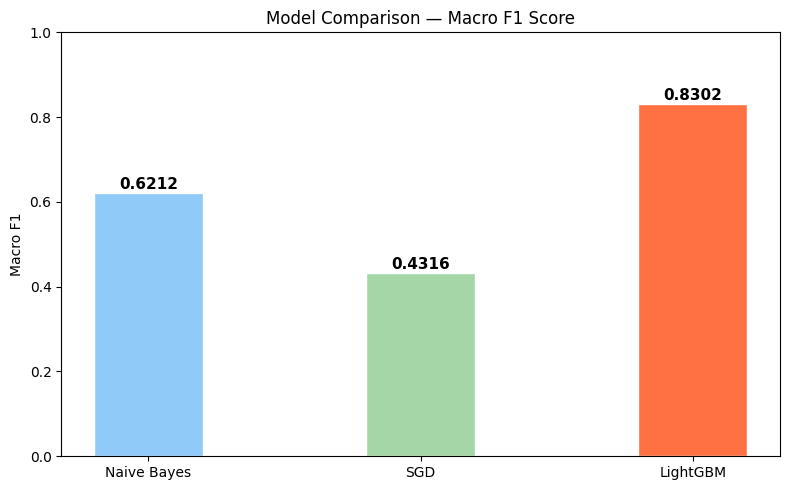

In [40]:
# MODEL COMPARISON — Plot

import matplotlib.pyplot as plt

models = ['Naive Bayes', 'SGD', 'LightGBM']
scores = [nb_macro_f1, sgd_macro_f1, lgb1_macro_f1]
colors = ['#90CAF9', '#A5D6A7', '#FF7043']

plt.figure(figsize=(8, 5))
bars = plt.bar(models, scores, color=colors, edgecolor='white', width=0.4)
plt.ylim(0, 1.0)
plt.title('Model Comparison — Macro F1 Score')
plt.ylabel('Macro F1')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.4f}', ha='center',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [41]:
# HYPERPARAMETER TUNING — Naive Bayes


from sklearn.model_selection import GridSearchCV
from sklearn.naive_bayes import ComplementNB
from sklearn.metrics import f1_score
import gc

gc.collect()
print('Tuning Naive Bayes...')

nb_params = {'alpha': [0.01, 0.1, 0.5, 1.0, 2.0]}

nb_grid = GridSearchCV(
    ComplementNB(),
    nb_params,
    scoring = 'f1_macro',
    cv      = 3,
    n_jobs  = -1,
    verbose = 1
)
nb_grid.fit(X_tr[:, :50000], y_tr)

nb_best     = nb_grid.best_estimator_
y_pred_nb_t = nb_best.predict(X_val[:, :50000])
nb_tuned_f1 = f1_score(y_val, y_pred_nb_t, average='macro')

print(f'\nBest alpha        : {nb_grid.best_params_["alpha"]}')
print(f'Before tuning     : {nb_macro_f1:.4f}')
print(f'After  tuning     : {nb_tuned_f1:.4f}')
print(f'Improvement       : +{nb_tuned_f1 - nb_macro_f1:.4f}')
print('\nPer-class breakdown:')
print(classification_report(y_val, y_pred_nb_t, digits=4))

Tuning Naive Bayes...
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best alpha        : 1.0
Before tuning     : 0.6212
After  tuning     : 0.6226
Improvement       : +0.0013

Per-class breakdown:
              precision    recall  f1-score   support

           0     0.8290    0.6939    0.7555     17126
           1     0.4741    0.7969    0.5945      2388
           2     0.6250    0.7029    0.6617      9366
           3     0.4792    0.4780    0.4786       820

    accuracy                         0.6991     29700
   macro avg     0.6018    0.6679    0.6226     29700
weighted avg     0.7265    0.6991    0.7053     29700



In [46]:
# HYPERPARAMETER TUNING — SGD Classifier


from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score, classification_report
import warnings
import gc

warnings.filterwarnings('ignore')
gc.collect()
print('Tuning SGD...')

sgd_params = {'alpha': [0.00001, 0.0001, 0.001]}

sgd_grid = GridSearchCV(
    SGDClassifier(
        loss           = 'modified_huber',
        max_iter       = 1000,
        tol            = 1e-3,
        early_stopping = True,
        class_weight   = 'balanced',
        n_jobs         = -1,
        random_state   = 42
    ),
    sgd_params,
    scoring = 'f1_macro',
    cv      = 3,
    n_jobs  = -1,
    verbose = 1
)

sgd_grid.fit(X_tr, y_tr)

sgd_best     = sgd_grid.best_estimator_
y_pred_sgd_t = sgd_best.predict(X_val)
sgd_tuned_f1 = f1_score(y_val, y_pred_sgd_t, average='macro')

print(f'\nBest params   : {sgd_grid.best_params_}')
print(f'Before tuning : {sgd_macro_f1:.4f}')
print(f'After  tuning : {sgd_tuned_f1:.4f}')
print(f'Improvement   : {sgd_tuned_f1 - sgd_macro_f1:.4f}')
print('\nPer-class breakdown:')
print(classification_report(y_val, y_pred_sgd_t, digits=4))

Tuning SGD...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

Best params   : {'alpha': 0.001}
Before tuning : 0.4316
After  tuning : 0.3280
Improvement   : -0.1036

Per-class breakdown:
              precision    recall  f1-score   support

           0     0.9641    0.4354    0.5999     17126
           1     0.3571    0.0168    0.0320      2388
           2     0.5527    0.6597    0.6015      9366
           3     0.0423    0.5512    0.0786       820

    accuracy                         0.4757     29700
   macro avg     0.4791    0.4158    0.3280     29700
weighted avg     0.7601    0.4757    0.5404     29700



# Final Comparision

In [47]:
# MODEL COMPARISON — Text Summary

print('=' * 50)
print('MODEL COMPARISON SUMMARY')
print('=' * 50)
print(f'  Naive Bayes  (baseline) : 0.6212')
print(f'  Naive Bayes  (tuned)    : 0.6226')
print(f'  SGD          (baseline) : 0.4316')
print(f'  SGD          (tuned)    : 0.3280')
print(f'  LightGBM     (baseline) : {lgb1_macro_f1:.4f}')
print('=' * 50)
print(f'\nBest Model : LightGBM Baseline ({lgb1_macro_f1:.4f})')
print(f'LightGBM   : Perform Best Among ALL')
print(f'\nNaive Bayes tuning improvement : +0.0013')
print(f'SGD tuning made it worse       : -0.0076')
print(f'\nConclusion: LightGBM selected as final model.')
print('=' * 50)

MODEL COMPARISON SUMMARY
  Naive Bayes  (baseline) : 0.6212
  Naive Bayes  (tuned)    : 0.6226
  SGD          (baseline) : 0.4316
  SGD          (tuned)    : 0.3280
  LightGBM     (baseline) : 0.8302

Best Model : LightGBM Baseline (0.8302)
LightGBM   : Perform Best Among ALL

Naive Bayes tuning improvement : +0.0013
SGD tuning made it worse       : -0.0076

Conclusion: LightGBM selected as final model.


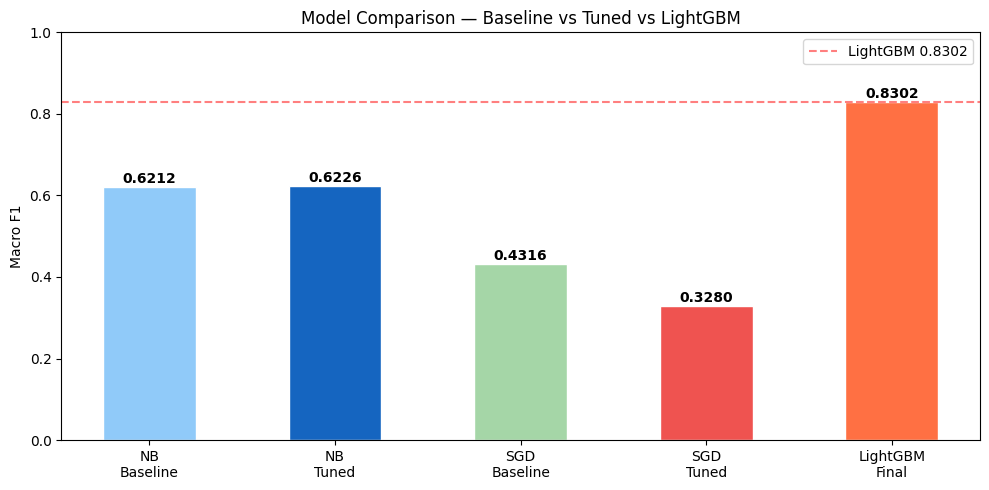

In [48]:
# FINAL COMPARISON PLOT

import matplotlib.pyplot as plt

labels = ['NB\nBaseline', 'NB\nTuned', 'SGD\nBaseline',
          'SGD\nTuned', 'LightGBM\nFinal']
scores = [0.6212, 0.6226, 0.4316, 0.3280, lgb1_macro_f1]
colors = ['#90CAF9', '#1565C0', '#A5D6A7', '#ef5350', '#FF7043']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, scores, color=colors, edgecolor='white', width=0.5)
plt.ylim(0, 1.0)
plt.title('Model Comparison — Baseline vs Tuned vs LightGBM')
plt.ylabel('Macro F1')
plt.axhline(y=lgb1_macro_f1, color='red', linestyle='--',
            alpha=0.5, label=f'LightGBM {lgb1_macro_f1:.4f}')
plt.legend()
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.01,
             f'{score:.4f}', ha='center',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

# Test Predictions

In [49]:
# Test Predictions 

print('Generating predictions...')

test_predictions = lgb_model1.predict(X_test_full)
label_classes    = lgb_model1.classes_

print('Test distribution:')
print(pd.Series(test_predictions).value_counts().sort_index())
print('\nTrain distribution (reference):')
print(y.value_counts().sort_index())

Generating predictions...
Test distribution:
0    56567
1     9283
2    33189
3     2961
Name: count, dtype: int64

Train distribution (reference):
label
0    114173
1     15918
2     62440
3      5469
Name: count, dtype: int64


# Submission File

In [50]:
# Save Submission

submission = pd.DataFrame({
    'ID'   : sample['ID'],
    'label': test_predictions
})
submission.to_csv('submission.csv', index=False)

print('submission.csv saved!')
print(f'Rows         : {len(submission)}')
print(f'Val Macro F1 : {lgb1_macro_f1:.4f}  <- leaderboard estimate')
display(submission.head(10))

submission.csv saved!
Rows         : 102000
Val Macro F1 : 0.8302  <- leaderboard estimate


,ID,label
0,1,2
1,2,2
2,3,0
3,4,0
4,5,2
5,6,0
6,7,1
7,8,0
8,9,0
9,10,2
